# Detecting Suspicious Financial Transactions Using Machine Learning

**Author:** Slavena Georgieva

---

## Abstract

*This section will be completed after the experiments and model evaluation have been finalized.*

---

# 1. Introduction

Financial institutions process millions of financial transactions every day, making manual monitoring for suspicious activity increasingly difficult. Anti-Money Laundering (AML) systems are designed to identify transactions that may indicate money laundering, terrorist financing, or other financial crimes. Traditionally, financial institutions rely on rule-based transaction monitoring systems, where predefined rules generate alerts for further investigation.

Although rule-based systems are effective for detecting known suspicious patterns, they often produce a large number of false positives and may fail to detect new or evolving money laundering techniques. As financial transactions continue to increase in volume and complexity, machine learning has emerged as a promising approach for improving transaction monitoring by learning patterns directly from historical data.

This project investigates the use of supervised machine learning algorithms to classify financial transactions as suspicious or non-suspicious using the SAML-D synthetic transaction monitoring dataset. Several classification models are trained and compared to determine which algorithm performs best for AML transaction monitoring. The project also demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, dimensionality reduction, model training and performance evaluation.

---

# 2. Project Objectives

The main objectives of this project are:

- To explore and understand the characteristics of financial transaction data.
- To perform exploratory data analysis (EDA) and identify important data patterns.
- To preprocess and prepare the dataset for machine learning.
- To prepare a representative dataset suitable for machine learning while addressing the class imbalance
- To engineer additional features that may improve model performance.
- To compare multiple supervised machine learning algorithms for suspicious transaction classification.
- To evaluate the models using appropriate classification metrics such as Precision, Recall, F1-score and ROC-AUC.
- To identify the model that provides the best overall performance for supporting AML transaction monitoring.

---

# 3. Problem Statement

Money laundering is a major global financial crime, accounting for an estimated 2–5% of the world's Gross Domestic Product (GDP) each year. Financial institutions are required to monitor customer transactions and identify potentially suspicious activity that may require further investigation.

Traditional AML monitoring systems are primarily based on predefined business rules. While these systems are effective for detecting known scenarios, they often generate a high number of false positive alerts and may struggle to identify increasingly sophisticated laundering techniques.

The objective of this project is to investigate whether supervised machine learning models can improve the detection of suspicious financial transactions by learning complex patterns directly from historical labeled transaction data. Special attention is given to the extreme class imbalance that naturally exists in AML datasets, where suspicious transactions represent only a very small fraction of all transactions. The project evaluates different machine learning algorithms and compares their effectiveness in supporting transaction monitoring through accurate suspicious transaction classification.

---

# 4. Dataset


## 4.1 Dataset Overview

The dataset used in this project is the **Synthetic Transaction Monitoring Dataset for Anti-Money Laundering (SAML-D)**, a publicly available synthetic dataset designed to simulate realistic financial transactions for Anti-Money Laundering (AML) research and machine learning applications.

The dataset contains approximately **9.5 million financial transactions** generated to represent both legitimate and money laundering activity. Each transaction includes information such as transaction amount, payment type, currencies, timestamps, account identifiers and bank locations.

The target variable is **`Is_laundering`**, which indicates whether a transaction is labelled as a money laundering transaction (1) or a normal transaction (0).

---

## 4.2 Dataset Features

The dataset contains both numerical and categorical variables describing different characteristics of each financial transaction. The following table summarises the variables used in this project.

In [1]:
import pandas as pd

feature_description = pd.DataFrame({
    "Feature": [
        "Time",
        "Date",
        "Sender_account",
        "Receiver_account",
        "Amount",
        "Payment_currency",
        "Received_currency",
        "Sender_bank_location",
        "Receiver_bank_location",
        "Payment_type",
        "Is_laundering",
        "Laundering_type"
    ],
    "Description": [
        "Transaction time",
        "Transaction date",
        "Sender account identifier",
        "Receiver account identifier",
        "Transaction amount",
        "Payment currency",
        "Received currency",
        "Sender bank location",
        "Receiver bank location",
        "Payment method",
        "Target variable indicating whether the transaction is related to money laundering",
        "Money laundering typology"
    ]
})

feature_description

,Feature,Description
0,Time,Transaction time
1,Date,Transaction date
2,Sender_account,Sender account identifier
3,Receiver_account,Receiver account identifier
4,Amount,Transaction amount
5,Payment_currency,Payment currency
6,Received_currency,Received currency
7,Sender_bank_location,Sender bank location
8,Receiver_bank_location,Receiver bank location
9,Payment_type,Payment method


## 4.3 Sampling Strategy

The original SAML-D dataset is highly imbalanced, containing approximately **9.5 million transactions**, of which only **9,873** are labelled as laundering transactions.

Training machine learning models directly on the complete dataset would require considerably more computational resources while providing little additional benefit for this project.

Therefore, a representative sample dataset was created by retaining **all 9,873 laundering transactions** and randomly selecting **190,000 normal transactions**. This produced a final dataset containing **199,873 transactions**, providing a substantially improved class distribution while preserving realistic transaction characteristics for machine learning experiments.

In [2]:
sampling_summary = pd.DataFrame({
    "Dataset": [
        "Original dataset",
        "Laundering transactions",
        "Sampled normal transactions",
        "Final sample dataset"
    ],
    "Transactions": [
        9504852,
        9873,
        190000,
        199873
    ]
})

sampling_summary

,Dataset,Transactions
0,Original dataset,9504852
1,Laundering transactions,9873
2,Sampled normal transactions,190000
3,Final sample dataset,199873


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the structure, quality and characteristics of the sampled dataset before applying machine learning algorithms.

The purpose of this stage is to identify potential data quality issues, understand feature distributions and explore relationships between variables that may influence model performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

In [4]:
# Load the sampled dataset

df = pd.read_csv("AML_sample.csv")

In [5]:
# Display dataset dimensions

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 199,873
Columns: 12


In [6]:
# Display the first five records

df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,19:28:16,2023-05-09,371655141,8045939247,3792.25,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
1,01:11:53,2023-08-01,1500297496,440699172,345.53,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Small_Fan_Out
2,11:19:15,2023-08-03,7775860537,7197849283,10128.69,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out
3,12:45:12,2023-06-09,3082029687,8404200332,18342.06,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Fan_In
4,04:44:01,2023-06-29,1179981989,8202066258,2345.67,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group


## 5.2 Dataset Overview

The sampled dataset contains both legitimate and laundering transactions together with several numerical and categorical features describing different aspects of each financial transaction.

Before building machine learning models, it is important to examine the overall structure of the dataset and verify that the data has been loaded correctly.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199873 entries, 0 to 199872
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    199873 non-null  str    
 1   Date                    199873 non-null  str    
 2   Sender_account          199873 non-null  int64  
 3   Receiver_account        199873 non-null  int64  
 4   Amount                  199873 non-null  float64
 5   Payment_currency        199873 non-null  str    
 6   Received_currency       199873 non-null  str    
 7   Sender_bank_location    199873 non-null  str    
 8   Receiver_bank_location  199873 non-null  str    
 9   Payment_type            199873 non-null  str    
 10  Is_laundering           199873 non-null  int64  
 11  Laundering_type         199873 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 18.3 MB


In [8]:
df.describe()

,Sender_account,Receiver_account,Amount,Is_laundering
count,1.998730e+05,1.998730e+05,1.998730e+05,199873.000000
mean,5.017235e+09,5.008801e+09,1.037462e+04,0.049396
std,2.881320e+09,2.886468e+09,9.594040e+04,0.216695
min,6.154900e+04,1.326600e+04,7.620000e+00,0.000000
25%,2.536172e+09,2.511292e+09,2.179530e+03,0.000000
50%,5.014125e+09,5.002957e+09,6.070920e+03,0.000000
75%,7.507463e+09,7.517524e+09,1.046119e+04,0.000000
max,9.999759e+09,9.999900e+09,1.261850e+07,1.000000


## 5.3 Missing Values

Missing values can negatively affect machine learning models and may require additional preprocessing. Therefore, the dataset is examined to determine whether any variables contain missing observations.

In [9]:
# Check for missing values

missing_values = df.isnull().sum()

missing_values

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [10]:
missing_values[missing_values > 0]

Series([], dtype: int64)

**Observation**

No missing values were found in the sampled dataset. Therefore, no imputation or removal of missing observations is required.

## 5.4 Duplicate Records

Duplicate records may introduce bias into machine learning models. Therefore, the dataset is checked for duplicated transactions.

In [13]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


**Observation**

No duplicate records were identified in the sampled dataset.

## 5.5 Class Distribution

Understanding the class distribution is particularly important because AML datasets are naturally highly imbalanced. The following chart illustrates the distribution of normal and laundering transactions within the sampled dataset.

In [15]:
class_counts = df["Is_laundering"].value_counts()

class_counts

Is_laundering
0    190000
1      9873
Name: count, dtype: int64

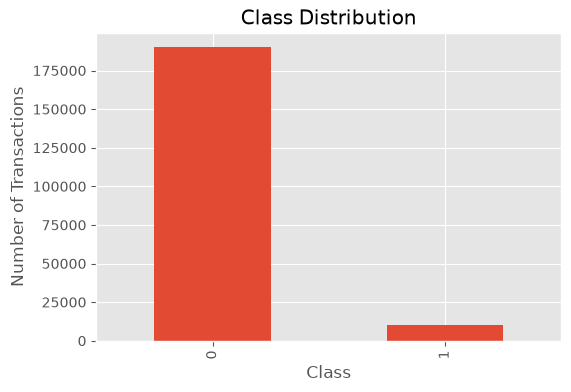

In [16]:
plt.figure(figsize=(6,4))

class_counts.plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

### Class Proportions

In [19]:
(class_counts / len(df) * 100).round(2)

Is_laundering
0    95.06
1     4.94
Name: count, dtype: float64

**Observation**

The sampled dataset remains imbalanced, although the class distribution is considerably improved compared to the original SAML-D dataset. All laundering transactions were retained, while a representative subset of normal transactions was selected to produce a dataset suitable for machine learning while preserving realistic characteristics.